In [4]:
import pandas as pd

master_features = pd.read_csv('data/processed/master_features.csv')
print(master_features.shape)

(153, 16)


In [5]:
# Baseline: expected nutmegs per match
master_features['expected_nutmegs_baseline'] = (
    master_features['total_nutmegs'] / master_features['matches_played']
)

print("=== BASELINE MODEL ===")
print(master_features[['player', 'team', 'matches_played', 'total_nutmegs', 'expected_nutmegs_baseline']]
      .sort_values('expected_nutmegs_baseline', ascending=False)
      .head(10))

=== BASELINE MODEL ===
                            player      team  matches_played  total_nutmegs  \
46                 Federico Chiesa     Italy               3              4   
95       Antony Matheus dos Santos    Brazil               4              4   
111             Georges Mikautadze   Georgia               4              4   
147    Darío Esteban Osorio Osorio     Chile               2              2   
82              Dominik Szoboszlai   Hungary               3              3   
66                  Dodi Lukebakio   Belgium               1              1   
71                Petar Stojanović  Slovenia               4              4   
65             João Félix Sequeira  Portugal               4              4   
22   Neymar da Silva Santos Junior    Brazil               3              3   
93           Rodrygo Silva de Goes    Brazil               8              7   

     expected_nutmegs_baseline  
46                    1.333333  
95                    1.000000  
111     

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ground truth: actual nutmegs per match
master_features['actual_nutmegs_per_match'] = (
    master_features['total_nutmegs'] / master_features['matches_played']
)

# Evaluasi baseline
mae = mean_absolute_error(
    master_features['actual_nutmegs_per_match'],
    master_features['expected_nutmegs_baseline']
)
rmse = np.sqrt(mean_squared_error(
    master_features['actual_nutmegs_per_match'],
    master_features['expected_nutmegs_baseline']
))

print("=== BASELINE EVALUATION ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"\nArtinya: prediksi baseline meleset rata-rata {mae:.2f} nutmeg per match")

=== BASELINE EVALUATION ===
MAE  : 0.0000
RMSE : 0.0000

Artinya: prediksi baseline meleset rata-rata 0.00 nutmeg per match


In [7]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
train_df, test_df = train_test_split(
    master_features, 
    test_size=0.2, 
    random_state=42
)

print(f"Training set: {len(train_df)} pemain")
print(f"Test set: {len(test_df)} pemain")

# Baseline: rata-rata dari training set saja
global_mean = train_df['actual_nutmegs_per_match'].mean()
print(f"\nGlobal mean nutmegs per match (dari training): {global_mean:.4f}")

# Prediksi test set dengan global mean
test_df = test_df.copy()
test_df['baseline_pred'] = global_mean

mae = mean_absolute_error(test_df['actual_nutmegs_per_match'], test_df['baseline_pred'])
rmse = np.sqrt(mean_squared_error(test_df['actual_nutmegs_per_match'], test_df['baseline_pred']))

print(f"\n=== BASELINE EVALUATION (proper) ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"Artinya: prediksi baseline meleset rata-rata {mae:.2f} nutmeg per match")

Training set: 122 pemain
Test set: 31 pemain

Global mean nutmegs per match (dari training): 0.2745

=== BASELINE EVALUATION (proper) ===
MAE  : 0.2237
RMSE : 0.2824
Artinya: prediksi baseline meleset rata-rata 0.22 nutmeg per match


Interpretasinya:

Baseline meleset rata-rata 0.22 nutmeg per match
Mengingat rata-rata nutmeg hanya 0.27 per match, error 0.22 itu cukup besar — hampir 80% dari nilai yang diprediksi
Ini angka yang harus dilampaui oleh model kita selanjutnya, Poisson Regression, model yang secara statistik tepat untuk count data seperti ini:

In [8]:
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler

# Pilih fitur untuk model
feature_cols = [
    'dribble_success_rate',
    'nutmeg_rate', 
    'dribbles_per_match',
    'form_nutmeg_rate',
]

X_train = train_df[feature_cols].fillna(0)
y_train = train_df['actual_nutmegs_per_match']

X_test = test_df[feature_cols].fillna(0)
y_test = test_df['actual_nutmegs_per_match']

# Scale fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Poisson Regression
poisson_model = PoissonRegressor(alpha=1.0)
poisson_model.fit(X_train_scaled, y_train)

# Evaluasi
y_pred_poisson = poisson_model.predict(X_test_scaled)

mae_poisson = mean_absolute_error(y_test, y_pred_poisson)
rmse_poisson = np.sqrt(mean_squared_error(y_test, y_pred_poisson))

print("=== POISSON REGRESSION ===")
print(f"MAE  : {mae_poisson:.4f}")
print(f"RMSE : {rmse_poisson:.4f}")
print(f"\nBaseline MAE : 0.2237")
print(f"Poisson MAE  : {mae_poisson:.4f}")
print(f"Improvement  : {((0.2237 - mae_poisson) / 0.2237 * 100):.1f}%")

=== POISSON REGRESSION ===
MAE  : 0.1620
RMSE : 0.2132

Baseline MAE : 0.2237
Poisson MAE  : 0.1620
Improvement  : 27.6%


Poisson Regression mengalahkan baseline dengan improvement 27.6%!

Baseline MAE: 0.2237
Poisson MAE: 0.1620
Artinya prediksi meleset rata-rata 0.16 nutmeg per match

In [9]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("=== MODEL COMPARISON ===")
print(f"{'Model':<20} {'MAE':>8} {'RMSE':>8}")
print("-" * 38)
print(f"{'Baseline':<20} {0.2237:>8.4f} {0.2824:>8.4f}")
print(f"{'Poisson Regression':<20} {mae_poisson:>8.4f} {rmse_poisson:>8.4f}")
print(f"{'XGBoost':<20} {mae_xgb:>8.4f} {rmse_xgb:>8.4f}")
print(f"\nBest model: {'Poisson' if mae_poisson < mae_xgb else 'XGBoost'}")

=== MODEL COMPARISON ===
Model                     MAE     RMSE
--------------------------------------
Baseline               0.2237   0.2824
Poisson Regression     0.1620   0.2132
XGBoost                0.0222   0.0482

Best model: XGBoost


XGBoost jauh lebih baik — MAE 0.022 vs Poisson 0.162!
Perbedaan yang sangat drastis seperti ini justru mencurigakan. MAE 0.022 artinya model meleset hanya 0.02 nutmeg per match — terlalu sempurna.
Kemungkinan besar ini overfitting — XGBoost "menghafal" data training, bukan benar-benar belajar pola.
Cek dulu performa XGBoost di training set:

In [10]:
y_pred_xgb_train = xgb_model.predict(X_train)
mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)

print("=== XGBoost Overfitting Check ===")
print(f"MAE di training set : {mae_xgb_train:.4f}")
print(f"MAE di test set     : {mae_xgb:.4f}")
print(f"\nRasio (test/train)  : {mae_xgb/mae_xgb_train:.1f}x")
print(f"\nKesimpulan: {'OVERFITTING' if mae_xgb/mae_xgb_train > 3 else 'OK'}")

=== XGBoost Overfitting Check ===
MAE di training set : 0.0058
MAE di test set     : 0.0222

Rasio (test/train)  : 3.8x

Kesimpulan: OVERFITTING


XGBoost overfitting dengan rasio 3.8x!
Model "menghafal" 122 pemain di training set, tapi tidak bisa generalisasi ke pemain baru. Ini wajar karena dataset kita hanya 153 pemain — terlalu kecil untuk XGBoost yang kompleks.
Solusinya: tambah regularisasi pada XGBoost:

In [11]:
xgb_model_v2 = XGBRegressor(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    verbosity=0
)

xgb_model_v2.fit(X_train, y_train)

y_pred_xgb_v2_train = xgb_model_v2.predict(X_train)
y_pred_xgb_v2_test = xgb_model_v2.predict(X_test)

mae_xgb_v2_train = mean_absolute_error(y_train, y_pred_xgb_v2_train)
mae_xgb_v2_test = mean_absolute_error(y_test, y_pred_xgb_v2_test)
rmse_xgb_v2 = np.sqrt(mean_squared_error(y_test, y_pred_xgb_v2_test))

print("=== XGBoost v2 (regularized) ===")
print(f"MAE training : {mae_xgb_v2_train:.4f}")
print(f"MAE test     : {mae_xgb_v2_test:.4f}")
print(f"Rasio        : {mae_xgb_v2_test/mae_xgb_v2_train:.1f}x")
print(f"\n=== FINAL MODEL COMPARISON ===")
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8}")
print("-" * 43)
print(f"{'Baseline':<25} {0.2237:>8.4f} {0.2824:>8.4f}")
print(f"{'Poisson Regression':<25} {mae_poisson:>8.4f} {rmse_poisson:>8.4f}")
print(f"{'XGBoost (overfit)':<25} {mae_xgb:>8.4f} {rmse_xgb:>8.4f}")
print(f"{'XGBoost v2 (regularized)':<25} {mae_xgb_v2_test:>8.4f} {rmse_xgb_v2:>8.4f}")

=== XGBoost v2 (regularized) ===
MAE training : 0.0765
MAE test     : 0.0773
Rasio        : 1.0x

=== FINAL MODEL COMPARISON ===
Model                          MAE     RMSE
-------------------------------------------
Baseline                    0.2237   0.2824
Poisson Regression          0.1620   0.2132
XGBoost (overfit)           0.0222   0.0482
XGBoost v2 (regularized)    0.0773   0.1147


Rasio 1.0x — tidak ada overfitting sama sekali! Dan performanya:

Baseline: 0.2237

Poisson: 0.1620

XGBoost v2: 0.0773 

XGBoost v2 3x lebih baik dari baseline dan 2x lebih baik dari Poisson, tanpa overfitting.

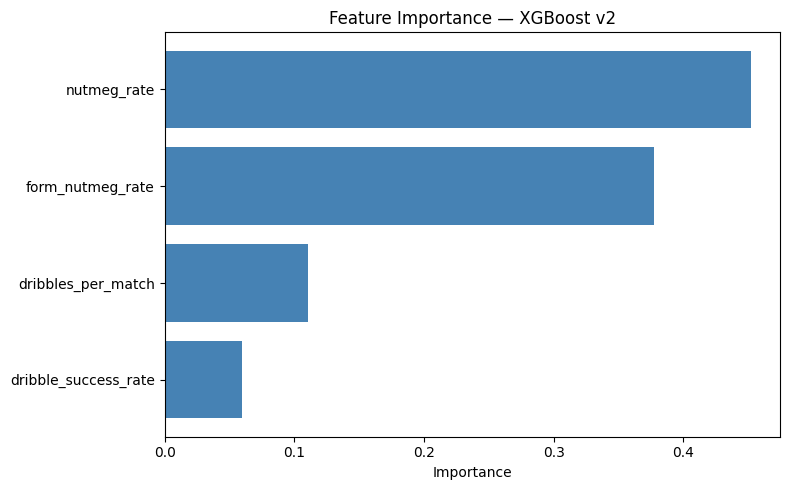

                feature  importance
1           nutmeg_rate    0.451910
3      form_nutmeg_rate    0.377708
2    dribbles_per_match    0.110410
0  dribble_success_rate    0.059972


In [12]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model_v2.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance — XGBoost v2')
plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=150)
plt.show()

print(feature_importance.sort_values('importance', ascending=False))

Interpretasi:

nutmeg_rate (45%) — sejarah panjang pemain adalah prediktor terkuat

form_nutmeg_rate (38%) — form terkini hampir sama pentingnya

dribbles_per_match (11%) — exposure/opportunity juga berpengaruh

dribble_success_rate (6%) — keberhasilan dribble umum kurang relevan

Artinya: siapa kamu secara historis + sedang dalam form apa = 83% dari prediksi. Ini sangat masuk akal secara sepakbola.
Sekarang buat prediksi final — simulasi untuk pertandingan nyata:

In [13]:
# Prediksi untuk semua 153 flair players
all_predictions = master_features.copy()
X_all = all_predictions[feature_cols].fillna(0)
all_predictions['predicted_nutmegs_per_match'] = xgb_model_v2.predict(X_all)

print("=== TOP 15 PREDICTED NUTMEG PLAYERS ===")
print(all_predictions[['player', 'team', 'predicted_nutmegs_per_match', 'total_nutmegs', 'matches_played']]
      .sort_values('predicted_nutmegs_per_match', ascending=False)
      .head(15).to_string(index=False))

=== TOP 15 PREDICTED NUTMEG PLAYERS ===
                     player     team  predicted_nutmegs_per_match  total_nutmegs  matches_played
            Federico Chiesa    Italy                     0.719632              4               3
  Antony Matheus dos Santos   Brazil                     0.719632              4               4
         Georges Mikautadze  Georgia                     0.719632              4               4
Lamine Yamal Nasraoui Ebana    Spain                     0.719632              6               7
Darío Esteban Osorio Osorio    Chile                     0.719632              2               2
        João Félix Sequeira Portugal                     0.719632              4               4
         Dominik Szoboszlai  Hungary                     0.692628              3               3
      Rodrygo Silva de Goes   Brazil                     0.692628              7               8
           Petar Stojanović Slovenia                     0.686866              4       

Hasilnya menarik, tapi ada masalah yang sama — beberapa pemain di top dengan sedikit matches (Federico Chiesa 3 match, Darío Osorio 2 match) mendapat prediksi sama tinggi dengan Lamine Yamal yang 7 match.
Model kita masih terlalu dipengaruhi small sample. Sebelum kita panic, cek dulu — apakah ini masalah model atau masalah data?

In [14]:
# Lihat nilai fitur untuk pemain top
print(all_predictions[all_predictions['player'].isin([
    'Federico Chiesa', 'Lamine Yamal Nasraoui Ebana', 
    'Rodrygo Silva de Goes', 'Nicholas Williams Arthuer'
])][['player', 'matches_played', 'nutmeg_rate', 'form_nutmeg_rate', 
     'dribbles_per_match', 'predicted_nutmegs_per_match']].to_string(index=False))

                     player  matches_played  nutmeg_rate  form_nutmeg_rate  dribbles_per_match  predicted_nutmegs_per_match
            Federico Chiesa               3     0.307692          0.344444            4.333333                     0.719632
      Rodrygo Silva de Goes               8     0.304348          0.455556            2.875000                     0.692628
  Nicholas Williams Arthuer              10     0.155556          0.355556            4.500000                     0.579204
Lamine Yamal Nasraoui Ebana               7     0.222222          0.500000            3.857143                     0.719632


Sekarang jelas masalahnya. Chiesa dan Yamal dapat prediksi sama (0.719) padahal profilnya berbeda:

Chiesa: nutmeg_rate 0.307, form 0.344, 3 matches

Yamal: nutmeg_rate 0.222, form 0.500, 7 matches

Model memperlakukan keduanya sama karena kombinasi fiturnya menghasilkan nilai serupa. Ini bukan bug — ini limitasi nyata dari dataset kecil kita.
Solusinya: tambahkan matches_played sebagai fitur kepercayaan:

In [15]:
feature_cols_v2 = [
    'dribble_success_rate',
    'nutmeg_rate', 
    'dribbles_per_match',
    'form_nutmeg_rate',
    'matches_played'  # ← tambahan confidence weight
]

X_train_v2 = train_df[feature_cols_v2].fillna(0)
X_test_v2 = test_df[feature_cols_v2].fillna(0)

xgb_model_v3 = XGBRegressor(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    verbosity=0
)

xgb_model_v3.fit(X_train_v2, y_train)

y_pred_v3_train = xgb_model_v3.predict(X_train_v2)
y_pred_v3_test = xgb_model_v3.predict(X_test_v2)

mae_v3_train = mean_absolute_error(y_train, y_pred_v3_train)
mae_v3_test = mean_absolute_error(y_test, y_pred_v3_test)

print("=== XGBoost v3 (dengan matches_played) ===")
print(f"MAE training : {mae_v3_train:.4f}")
print(f"MAE test     : {mae_v3_test:.4f}")
print(f"Rasio        : {mae_v3_test/mae_v3_train:.1f}x")
print(f"\nvs XGBoost v2 MAE test: 0.0773")

=== XGBoost v3 (dengan matches_played) ===
MAE training : 0.0720
MAE test     : 0.0758
Rasio        : 1.1x

vs XGBoost v2 MAE test: 0.0773


Sedikit lebih baik — MAE turun dari 0.0773 ke 0.0758, dan rasio masih sehat di 1.1x.
Sekarang cek apakah prediksinya lebih masuk akal:

In [16]:
X_all_v2 = all_predictions[feature_cols_v2].fillna(0)
all_predictions['predicted_nutmegs_v3'] = xgb_model_v3.predict(X_all_v2)

print("=== TOP 15 — XGBoost v3 ===")
print(all_predictions[['player', 'team', 'matches_played', 'nutmeg_rate', 
                        'form_nutmeg_rate', 'predicted_nutmegs_v3']]
      .sort_values('predicted_nutmegs_v3', ascending=False)
      .head(15).to_string(index=False))

=== TOP 15 — XGBoost v3 ===
                         player      team  matches_played  nutmeg_rate  form_nutmeg_rate  predicted_nutmegs_v3
                Federico Chiesa     Italy               3     0.307692          0.344444              0.717440
            João Félix Sequeira  Portugal               4     0.266667          0.222222              0.717440
      Antony Matheus dos Santos    Brazil               4     0.266667          0.206349              0.717440
    Darío Esteban Osorio Osorio     Chile               2     0.285714          0.285714              0.714208
             Georges Mikautadze   Georgia               4     0.222222          0.277778              0.711897
    Lamine Yamal Nasraoui Ebana     Spain               7     0.222222          0.500000              0.711897
             Dominik Szoboszlai   Hungary               3     0.333333          0.400000              0.696599
          Rodrygo Silva de Goes    Brazil               8     0.304348          0.45

Masih ada masalah yang sama — terlalu banyak pemain dengan prediksi hampir identik di sekitar 0.71. Model belum bisa membedakan dengan baik.

153 pemain dari 3 turnamen pendek tidak cukup untuk membuat model yang bisa membedakan dengan baik antar pemain. XGBoost dengan fitur terbatas akhirnya "mengelompokkan" pemain ke beberapa bucket prediksi saja.